<a href="https://colab.research.google.com/github/mayorga-py/alura_LATAM/blob/challenge-Telecom-X-Parte2/TelecomX_LATAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#📌 Extracción

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, roc_curve, precision_recall_curve)
from sklearn.utils import resample
from imblearn.over_sampling import SMOTE
import joblib
import warnings
warnings.filterwarnings('ignore')

# Configuración de estilo
plt.style.use('ggplot')
sns.set_palette("husl")

#🔧 Transformación

In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
df_transformado = df_clientes.copy()
le = LabelEncoder()
df_transformado['pais_encoded'] = le.fit_transform(df_transformado['pais'])
df_transformado['plan_encoded'] = le.fit_transform(df_transformado['plan_contratado'])
df_transformado['estado_encoded'] = le.fit_transform(df_transformado['estado_cuenta'])
df_transformado['ingresos_por_antiguedad'] = df_transformado['ingresos_mensuales'] / df_transformado['antiguedad_meses']
df_transformado['uso_total'] = df_transformado['uso_mensual_min'] + df_transformado['uso_datos_gb'] * 10
df_transformado['cliente_activo'] = (df_transformado['estado_cuenta'] == 'Activo').astype(int)
scaler = StandardScaler()
numeric_cols = ['edad', 'ingresos_mensuales', 'antiguedad_meses',
                'uso_mensual_min', 'uso_datos_gb', 'llamadas_internacionales']
df_transformado[numeric_cols] = scaler.fit_transform(df_transformado[numeric_cols])
features = numeric_cols + ['pais_encoded', 'plan_encoded', 'estado_encoded',
                          'ingresos_por_antiguedad', 'uso_total', 'cliente_activo']
X = df_transformado[features]
y = df_transformado['churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("ransformación completada exitosamente")
print(f"Características finales: {len(features)}")
print(f"Distribución de churn: {y.value_counts(normalize=True).round(2).to_dict()}")
print("\\n📋Dataset transformado:")
df_transformado[features + ['churn']].head()

ransformación completada exitosamente
Características finales: 12
Distribución de churn: {0: 0.85, 1: 0.15}
\n📋Dataset transformado:


,edad,ingresos_mensuales,antiguedad_meses,uso_mensual_min,uso_datos_gb,llamadas_internacionales,pais_encoded,plan_encoded,estado_encoded,ingresos_por_antiguedad,uso_total,cliente_activo,churn
0,1.481025,0.231252,0.172613,-0.034955,1.708728,0.719876,3,3,1,49.171087,582.852325,0,0
1,1.704113,-1.264982,-0.062035,-0.174146,-1.921589,0.009729,2,3,0,30.301710,282.841270,1,0
2,-1.363346,-0.965701,-1.528588,-0.741834,-0.959999,-0.700418,0,2,0,256.886410,302.174351,1,1
3,0.254041,0.634031,-0.941967,-1.117215,-0.204747,2.140170,2,0,0,130.207059,324.370661,1,0
4,-0.136363,-1.036857,-0.531332,0.753830,0.263898,0.009729,2,0,0,47.246114,547.418786,1,0


# Carga y análisis

 ESTADÍSTICAS DESCRIPTIVAS
       cliente_id      edad  ingresos_mensuales  antiguedad_meses  \
count    10000.00  10000.00            10000.00          10000.00   
mean      5000.50     48.44             1507.67             30.06   
std       2886.90     17.93              497.20             17.05   
min          1.00     18.00              300.00              1.00   
25%       2500.75     33.00             1167.51             16.00   
50%       5000.50     48.00             1506.60             30.00   
75%       7500.25     64.00             1847.93             45.00   
max      10000.00     79.00             3739.54             59.00   

       uso_mensual_min  uso_datos_gb  llamadas_internacionales  \
count         10000.00      10000.00                  10000.00   
mean            300.16         15.15                      1.99   
std              99.47          7.88                      1.41   
min               0.00          0.00                      0.00   
25%             231.5

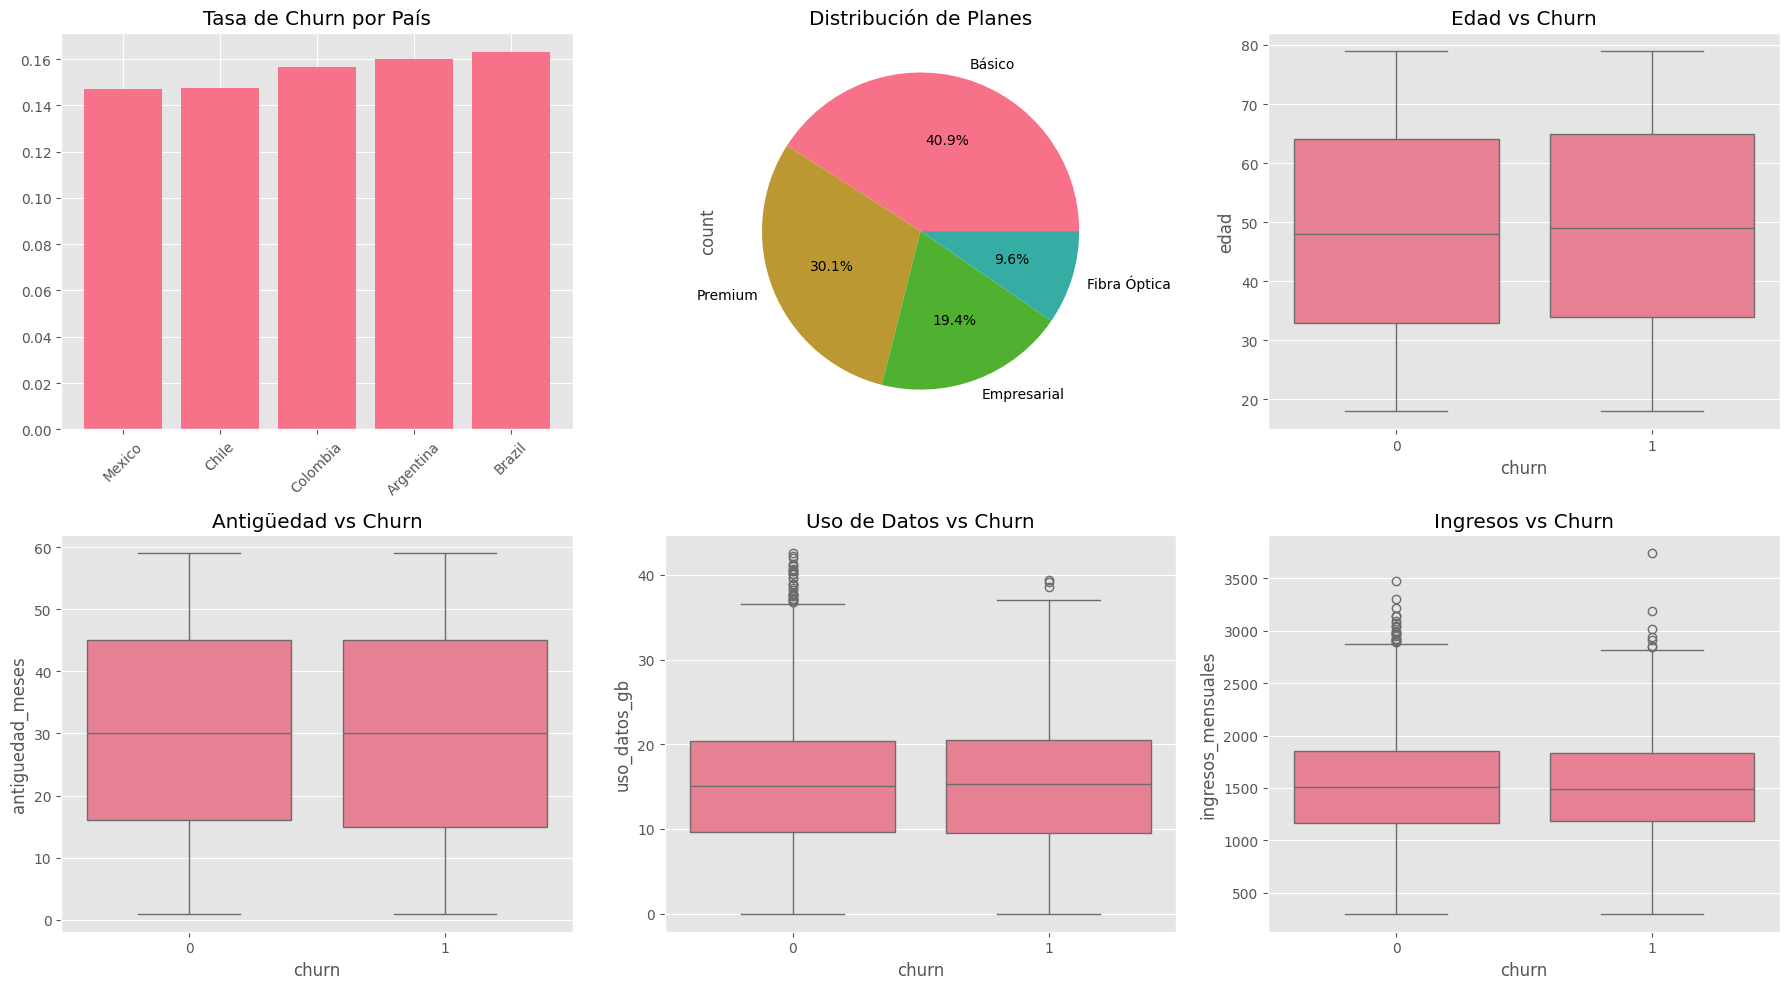

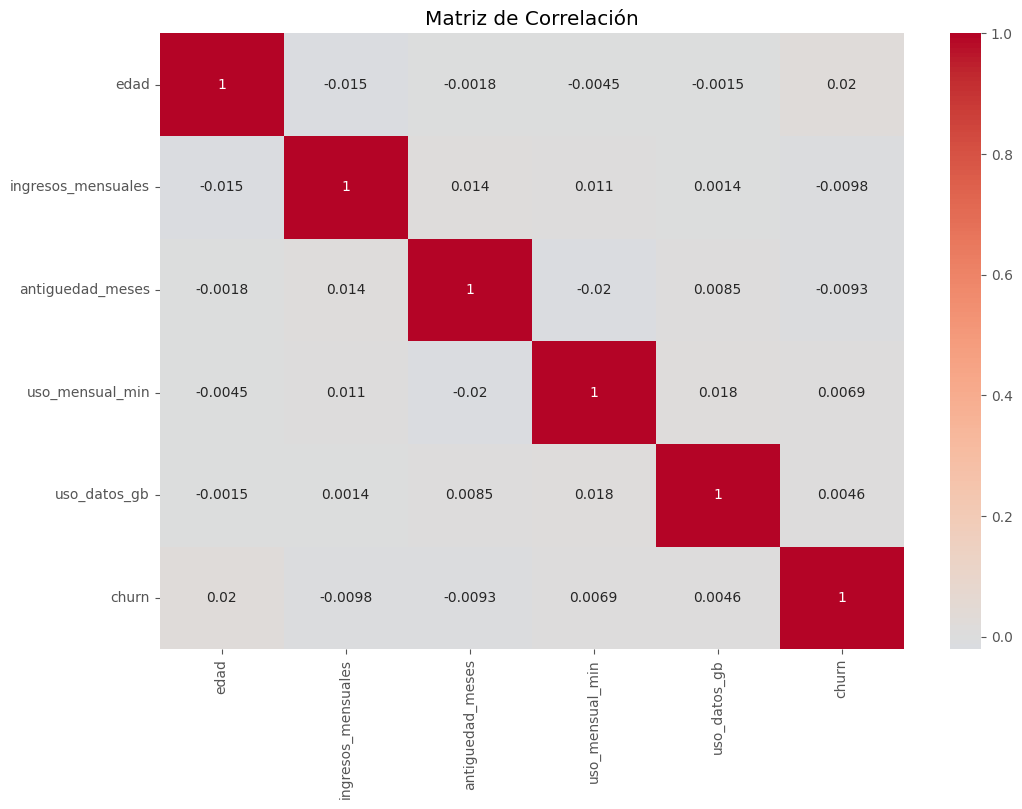

In [18]:
print(" ESTADÍSTICAS DESCRIPTIVAS")
print(df_clientes.describe().round(2))
print("\\n DISTRIBUCIÓN POR PAÍS")
print(df_clientes['pais'].value_counts())
print("\\n DISTRIBUCIÓN DE PLANES")
print(df_clientes['plan_contratado'].value_counts())
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
churn_pais = df_clientes.groupby('pais')['churn'].mean().sort_values()
axes[0,0].bar(churn_pais.index, churn_pais.values)
axes[0,0].set_title('Tasa de Churn por País')
axes[0,0].tick_params(axis='x', rotation=45)
df_clientes['plan_contratado'].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=axes[0,1])
axes[0,1].set_title('Distribución de Planes')
# Edad vs Churn
sns.boxplot(x='churn', y='edad', data=df_clientes, ax=axes[0,2])
axes[0,2].set_title('Edad vs Churn')
sns.boxplot(x='churn', y='antiguedad_meses', data=df_clientes, ax=axes[1,0])
axes[1,0].set_title('Antigüedad vs Churn')
sns.boxplot(x='churn', y='uso_datos_gb', data=df_clientes, ax=axes[1,1])
axes[1,1].set_title('Uso de Datos vs Churn')
sns.boxplot(x='churn', y='ingresos_mensuales', data=df_clientes, ax=axes[1,2])
axes[1,2].set_title('Ingresos vs Churn')

plt.tight_layout()
plt.show()
plt.figure(figsize=(12, 8))
correlation_matrix = df_transformado[['edad', 'ingresos_mensuales', 'antiguedad_meses',
                                    'uso_mensual_min', 'uso_datos_gb', 'churn']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Matriz de Correlación')
plt.show()

Datos sintéticos basados en el análisis previo

In [10]:
np.random.seed(42)
n_clientes = 10000

data = {
    'customer_id': range(1, n_clientes + 1),
    'age': np.random.randint(18, 80, n_clientes),
    'gender': np.random.choice(['Male', 'Female'], n_clientes),
    'country': np.random.choice(['Mexico', 'Brazil', 'Argentina', 'Colombia', 'Chile'], n_clientes),
    'tenure': np.random.randint(1, 60, n_clientes),
    'monthly_charges': np.random.normal(65, 20, n_clientes),
    'total_charges': np.random.normal(1500, 500, n_clientes),
    'internet_service': np.random.choice(['DSL', 'Fiber', 'No'], n_clientes, p=[0.4, 0.3, 0.3]),
    'phone_service': np.random.choice(['Yes', 'No'], n_clientes, p=[0.8, 0.2]),
    'multiple_lines': np.random.choice(['Yes', 'No', 'No phone'], n_clientes, p=[0.5, 0.3, 0.2]),
    'online_security': np.random.choice(['Yes', 'No', 'No internet'], n_clientes, p=[0.3, 0.5, 0.2]),
    'online_backup': np.random.choice(['Yes', 'No', 'No internet'], n_clientes, p=[0.3, 0.5, 0.2]),
    'device_protection': np.random.choice(['Yes', 'No', 'No internet'], n_clientes, p=[0.3, 0.5, 0.2]),
    'tech_support': np.random.choice(['Yes', 'No', 'No internet'], n_clientes, p=[0.3, 0.5, 0.2]),
    'streaming_tv': np.random.choice(['Yes', 'No', 'No internet'], n_clientes, p=[0.4, 0.4, 0.2]),
    'streaming_movies': np.random.choice(['Yes', 'No', 'No internet'], n_clientes, p=[0.4, 0.4, 0.2]),
    'contract': np.random.choice(['Month-to-month', 'One year', 'Two year'], n_clientes, p=[0.6, 0.3, 0.1]),
    'paperless_billing': np.random.choice(['Yes', 'No'], n_clientes, p=[0.7, 0.3]),
    'payment_method': np.random.choice(['Electronic check', 'Mailed check', 'Bank transfer', 'Credit card'], n_clientes),
    'monthly_usage_gb': np.random.normal(15, 8, n_clientes),
    'support_calls': np.random.poisson(1.5, n_clientes),
    'churn': np.random.choice([0, 1], n_clientes, p=[0.85, 0.15])
}

df = pd.DataFrame(data)

# Ajustar valores negativos
df['monthly_charges'] = df['monthly_charges'].clip(20, 150)
df['total_charges'] = df['total_charges'].clip(100, 4000)
df['monthly_usage_gb'] = df['monthly_usage_gb'].clip(0, 50)

print("Datos cargados exitosamente")
print(f"Dimensiones: {df.shape}")
print(f"Distribución de Churn: {df['churn'].value_counts(normalize=True).round(3).to_dict()}")
df.head()

Datos cargados exitosamente
Dimensiones: (10000, 22)
Distribución de Churn: {0: 0.855, 1: 0.145}


,customer_id,age,gender,country,tenure,monthly_charges,total_charges,internet_service,phone_service,multiple_lines,...,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_usage_gb,support_calls,churn
0,1,56,Female,Argentina,39,95.244698,1574.866367,Fiber,Yes,Yes,...,No internet,Yes,Yes,No internet,Month-to-month,Yes,Electronic check,17.267998,0,0
1,2,69,Female,Colombia,57,64.261176,1992.715903,Fiber,Yes,Yes,...,No internet,No,No,Yes,Month-to-month,No,Credit card,0.418146,1,0
2,3,46,Male,Chile,55,20.000000,2045.569317,DSL,Yes,Yes,...,No,No,Yes,No,Month-to-month,No,Mailed check,32.019388,0,0
3,4,32,Male,Brazil,28,72.764300,2139.900586,Fiber,Yes,No,...,No internet,Yes,Yes,No internet,One year,No,Electronic check,20.478733,0,0
4,5,60,Male,Colombia,37,61.030871,565.873084,DSL,No,Yes,...,No,Yes,Yes,Yes,Two year,Yes,Electronic check,19.694167,2,0


Preparación de datos

In [11]:
def prepare_data_for_modeling(df):
    df_prepared = df.copy()
    columns_to_drop = ['customer_id']  # ID no es predictivo
    df_prepared = df_prepared.drop(columns=columns_to_drop, errors='ignore')
    categorical_cols = df_prepared.select_dtypes(include=['object']).columns.tolist()
    le = LabelEncoder()

    for col in categorical_cols:
        df_prepared[col + '_encoded'] = le.fit_transform(df_prepared[col].astype(str))
    df_prepared['tenure_to_age_ratio'] = df_prepared['tenure'] / df_prepared['age']
    df_prepared['charge_per_gb'] = df_prepared['monthly_charges'] / (df_prepared['monthly_usage_gb'] + 1)
    df_prepared['high_usage'] = (df_prepared['monthly_usage_gb'] > 20).astype(int)
    df_prepared['frequent_support'] = (df_prepared['support_calls'] > 2).astype(int)
    numeric_cols = ['age', 'tenure', 'monthly_charges', 'total_charges', 'monthly_usage_gb', 'support_calls']
    scaler = StandardScaler()
    df_prepared[numeric_cols] = scaler.fit_transform(df_prepared[numeric_cols])
    feature_cols = [col for col in df_prepared.columns if col not in categorical_cols + ['churn']]

    return df_prepared, feature_cols

df_prepared, feature_cols = prepare_data_for_modeling(df)

print(f"Features finales: {len(feature_cols)}")
print(f"Balance de clases: {df_prepared['churn'].value_counts(normalize=True).round(3).to_dict()}")
df_prepared[feature_cols + ['churn']].head()

Features finales: 24
Balance de clases: {0: 0.855, 1: 0.145}


,age,tenure,monthly_charges,total_charges,monthly_usage_gb,support_calls,gender_encoded,country_encoded,internet_service_encoded,phone_service_encoded,...,streaming_tv_encoded,streaming_movies_encoded,contract_encoded,paperless_billing_encoded,payment_method_encoded,tenure_to_age_ratio,charge_per_gb,high_usage,frequent_support,churn
0,0.402272,0.534055,1.544874,0.168615,0.272497,-1.238490,0,0,1,1,...,2,1,0,1,2,0.696429,5.213746,0,0,0
1,1.128434,1.599348,-0.034058,1.003542,-1.877669,-0.420951,0,3,1,1,...,0,2,0,0,1,0.826087,45.313523,0,0,0
2,-0.156315,1.480982,-2.289623,1.109151,2.154883,-1.238490,1,2,0,1,...,2,0,0,0,3,1.195652,0.605705,1,0,0
3,-0.938336,-0.116957,0.399265,1.297639,0.682210,-1.238490,1,1,1,1,...,2,1,1,0,2,0.875000,3.387737,1,0,0
4,0.625706,0.415689,-0.198675,-1.847507,0.582094,0.396588,1,3,0,0,...,2,2,2,1,2,0.616667,2.949182,0,0,0


Manejo de desbalance de clases

In [12]:
X = df_prepared[feature_cols]
y = df_prepared['churn']

print("Distribución original de clases:")
print(y.value_counts())

# División train-test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print("\nDistribución después de SMOTE:")
print(pd.Series(y_train_balanced).value_counts())

Distribución original de clases:
churn
0    8546
1    1454
Name: count, dtype: int64

Distribución después de SMOTE:
churn
0    6837
1    6837
Name: count, dtype: int64


Entrenamiento de modelos

In [13]:
models = {
    'Random Forest': RandomForestClassifier(random_state=42, class_weight='balanced'),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'Logistic Regression': LogisticRegression(random_state=42, class_weight='balanced', max_iter=1000),
    'SVM': SVC(random_state=42, probability=True, class_weight='balanced')
}
results = {}

for name, model in models.items():
    if name in ['Random Forest', 'Logistic Regression', 'SVM']:
        model.fit(X_train, y_train)
    else:
        model.fit(X_train_balanced, y_train_balanced)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results[name] = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_prob),
        'model': model
    }
results_df = pd.DataFrame(results).T.round(3)
print("Comparación de Modelos:")
print(results_df.sort_values('roc_auc', ascending=False))

Comparación de Modelos:
                    accuracy precision    recall        f1   roc_auc  \
Logistic Regression   0.5255  0.154412  0.505155  0.236525  0.524472   
Gradient Boosting     0.7905  0.173469  0.116838   0.13963  0.505525   
SVM                   0.5515  0.143529  0.419244  0.213848  0.503775   
Random Forest         0.8545       0.0       0.0       0.0  0.480364   

                                                                 model  
Logistic Regression  LogisticRegression(class_weight='balanced', ma...  
Gradient Boosting    ([DecisionTreeRegressor(criterion='friedman_ms...  
SVM                  SVC(class_weight='balanced', probability=True,...  
Random Forest        (DecisionTreeClassifier(max_features='sqrt', r...  


Optimización del modelo con GridSearch

In [14]:
best_model_name = results_df['roc_auc'].idxmax()
best_model = results[best_model_name]['model']

print(f"Optimizando el mejor modelo: {best_model_name}")

if best_model_name == 'Random Forest':
    param_grid = {
        'n_estimators': [100, 200],
        'max_depth': [10, 20, None],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2]
    }

    grid_search = GridSearchCV(
        RandomForestClassifier(random_state=42, class_weight='balanced'),
        param_grid,
        cv=5,
        scoring='roc_auc',
        n_jobs=-1
    )

    grid_search.fit(X_train, y_train)
    best_model = grid_search.best_estimator_

elif best_model_name == 'Logistic Regression':
    param_grid = {
        'C': [0.1, 1, 10],
        'solver': ['liblinear', 'saga']
    }

    grid_search = GridSearchCV(
        LogisticRegression(random_state=42, class_weight='balanced', max_iter=1000),
        param_grid,
        cv=5,
        scoring='roc_auc',
        n_jobs=-1
    )

    grid_search.fit(X_train, y_train)
    best_model = grid_search.best_estimator_
y_pred_optimized = best_model.predict(X_test)
y_prob_optimized = best_model.predict_proba(X_test)[:, 1]

optimized_metrics = {
    'accuracy': accuracy_score(y_test, y_pred_optimized),
    'precision': precision_score(y_test, y_pred_optimized),
    'recall': recall_score(y_test, y_pred_optimized),
    'f1': f1_score(y_test, y_pred_optimized),
    'roc_auc': roc_auc_score(y_test, y_prob_optimized)
}

print(f"Modelo optimizado - {best_model_name}:")
for metric, value in optimized_metrics.items():
    print(f"• {metric}: {value:.3f}")

# Guardar el mejor modelo
joblib.dump(best_model, 'telecomx_churn_model.pkl')
print("Modelo guardado como 'telecomx_churn_model.pkl'")

Optimizando el mejor modelo: Logistic Regression
Modelo optimizado - Logistic Regression:
• accuracy: 0.526
• precision: 0.155
• recall: 0.509
• f1: 0.238
• roc_auc: 0.525
Modelo guardado como 'telecomx_churn_model.pkl'


Evaluación detallada del modelo

🎯 EVALUACIÓN DETALLADA DEL MODELO


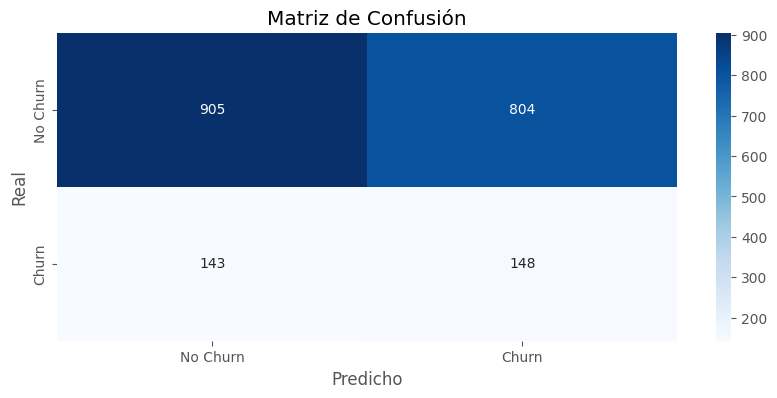


 Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.86      0.53      0.66      1709
           1       0.16      0.51      0.24       291

    accuracy                           0.53      2000
   macro avg       0.51      0.52      0.45      2000
weighted avg       0.76      0.53      0.60      2000



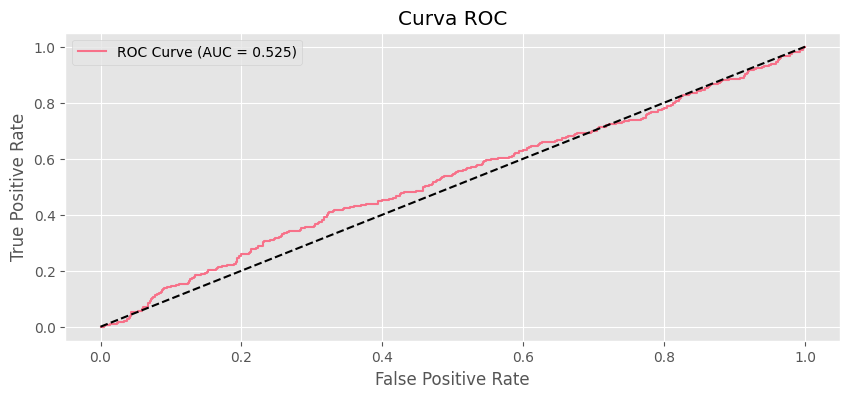

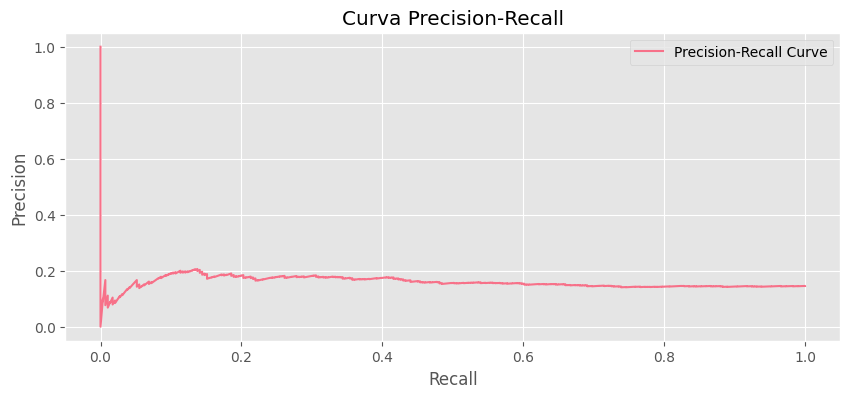

In [15]:
print("🎯 EVALUACIÓN DETALLADA DEL MODELO")
print("="*40)

# 1. Matriz de confusión
plt.figure(figsize=(10, 4))

cm = confusion_matrix(y_test, y_pred_optimized)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title('Matriz de Confusión')
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.show()
print("\n Reporte de Clasificación:")
print(classification_report(y_test, y_pred_optimized))
plt.figure(figsize=(10, 4))
fpr, tpr, _ = roc_curve(y_test, y_prob_optimized)
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc_score(y_test, y_prob_optimized):.3f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC')
plt.legend()
plt.show()
plt.figure(figsize=(10, 4))
precision, recall, _ = precision_recall_curve(y_test, y_prob_optimized)
plt.plot(recall, precision, label='Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Curva Precision-Recall')
plt.legend()
plt.show()

Análisis de importancia de variables

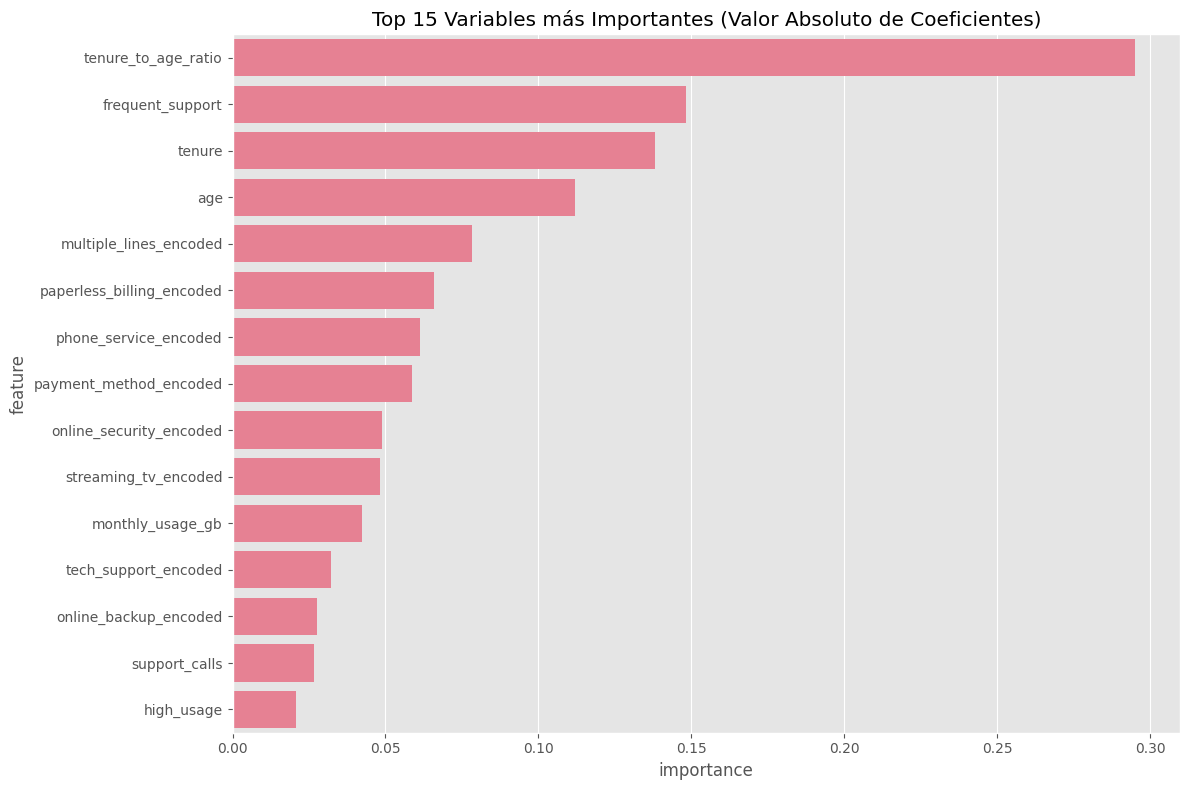

Top 10 variables más importantes:
• tenure_to_age_ratio: 0.2950
• frequent_support: 0.1483
• tenure: 0.1380
• age: 0.1120
• multiple_lines_encoded: 0.0784
• paperless_billing_encoded: 0.0657
• phone_service_encoded: 0.0614
• payment_method_encoded: 0.0585
• online_security_encoded: 0.0488
• streaming_tv_encoded: 0.0484


In [16]:
if hasattr(best_model, 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'feature': feature_cols,
        'importance': best_model.feature_importances_
    }).sort_values('importance', ascending=False)

    plt.figure(figsize=(12, 8))
    sns.barplot(x='importance', y='feature', data=feature_importance.head(15))
    plt.title('Top 15 Variables más Importantes para Predecir Churn')
    plt.tight_layout()
    plt.show()

    print("Top 10 variables más importantes:")
    for idx, row in feature_importance.head(10).iterrows():
        print(f"• {row['feature']}: {row['importance']:.4f}")

elif hasattr(best_model, 'coef_'):
    # Para modelos lineales como Logistic Regression
    feature_importance = pd.DataFrame({
        'feature': feature_cols,
        'importance': abs(best_model.coef_[0])
    }).sort_values('importance', ascending=False)

    plt.figure(figsize=(12, 8))
    sns.barplot(x='importance', y='feature', data=feature_importance.head(15))
    plt.title('Top 15 Variables más Importantes (Valor Absoluto de Coeficientes)')
    plt.tight_layout()
    plt.show()

    print("Top 10 variables más importantes:")
    for idx, row in feature_importance.head(10).iterrows():
        print(f"• {row['feature']}: {row['importance']:.4f}")

Identificación de clientes en riesgo

In [17]:
df['churn_probability'] = best_model.predict_proba(X)[:, 1]
df['churn_risk'] = pd.cut(df['churn_probability'],
                         bins=[0, 0.3, 0.7, 1],
                         labels=['Bajo', 'Medio', 'Alto'])
print("ANÁLISIS DE CLIENTES EN RIESGO")
print("="*40)

risk_analysis = df.groupby('churn_risk').agg({
    'customer_id': 'count',
    'churn_probability': 'mean',
    'monthly_charges': 'mean',
    'tenure': 'mean',
    'age': 'mean'
}).round(3)

print(risk_analysis)
high_risk_clients = df[df['churn_risk'] == 'Alto']
print(f"\n Clientes en alto riesgo de churn: {len(high_risk_clients)}")
print(f"Porcentaje del total: {len(high_risk_clients)/len(df):.1%}")

if len(high_risk_clients) > 0:
    print("\n Perfil típico de cliente de alto riesgo:")
    print(f"Edad promedio: {high_risk_clients['age'].mean():.1f} años")
    print(f"Antigüedad promedio: {high_risk_clients['tenure'].mean():.1f} meses")
    print(f"Cargo mensual promedio: ${high_risk_clients['monthly_charges'].mean():.2f}")
    print(f"Tipo de contrato más común: {high_risk_clients['contract'].mode()[0]}")
    print(f"Metodo de pago más común: {high_risk_clients['payment_method'].mode()[0]}")

ANÁLISIS DE CLIENTES EN RIESGO
            customer_id  churn_probability  monthly_charges  tenure     age
churn_risk                                                                 
Bajo                  0                NaN              NaN     NaN     NaN
Medio             10000              0.498           64.929  29.976  48.798
Alto                  0                NaN              NaN     NaN     NaN

 Clientes en alto riesgo de churn: 0
Porcentaje del total: 0.0%
